<a href="https://colab.research.google.com/github/adnanmk-1999/Subpixel_Shift_CNN/blob/main/subpixel_proof.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Theoretical Proof: Maximum Subpixel Resolution in 8-Bit Images

This notebook mathematically proves why the absolute physical limit of shift detection in an 8-bit grayscale image is exactly **1/255 of a pixel**.

We will break down the geometry, the quantization limits, and run a Python simulation to visualize how image contrast affects your model's accuracy.

### Premise 1: The Ideal Edge (Maximum Contrast)
To find the absolute best-case scenario for detecting movement, we must assume the image contains a feature with the maximum possible contrast. In an 8-bit grayscale image, pixel values range from 0 (pure black) to 255 (pure white).

---

### Premise 2: Continuous Light vs. Discrete Pixels
A pixel acts as a bucket collecting light. Assuming light distributes linearly as a perfect, sharp edge moves across a pixel, we can define the maximum intensity gradient ($G_{max}$).

If moving the edge by $1.0$ full pixel changes the brightness by $255$ levels, the gradient is:
$$G_{max} = \frac{\Delta I}{\Delta x} = \frac{255}{1}$$

---

### Premise 3: The 8-Bit Quantization Floor
Because the image is saved in an 8-bit digital format (like PNG), it cannot record fractional brightness values. It must round to the nearest whole integer.

Therefore, the absolute smallest change in intensity ($\Delta I_{min}$) that the computer can "see" is exactly $1$ level.
$$\Delta I_{min} = 1$$

---

### The Derivation
We take our gradient equation and solve for the minimum spatial shift ($\Delta x_{min}$) required to physically trigger that 1-level change in the image file:
$$\Delta x = \frac{\Delta I}{G_{max}}$$
$$\Delta x_{min} = \frac{1}{255}$$
$$\Delta x_{min} \approx 0.00392$$

**Conclusion:** The absolute mathematical limit of 8-bit subpixel resolution is **0.00392 pixels**.

## Real-World Implications: Diminishing Contrast
The proof above assumes a perfect 0 to 255 contrast. If your image features lower contrast (e.g., a gray dot of intensity 150 on a dark gray background of 50), the maximum gradient drops, and the minimum detectable shift increases.

Run the Python code below to visualize how image contrast mathematically restricts your maximum achievable subpixel accuracy.

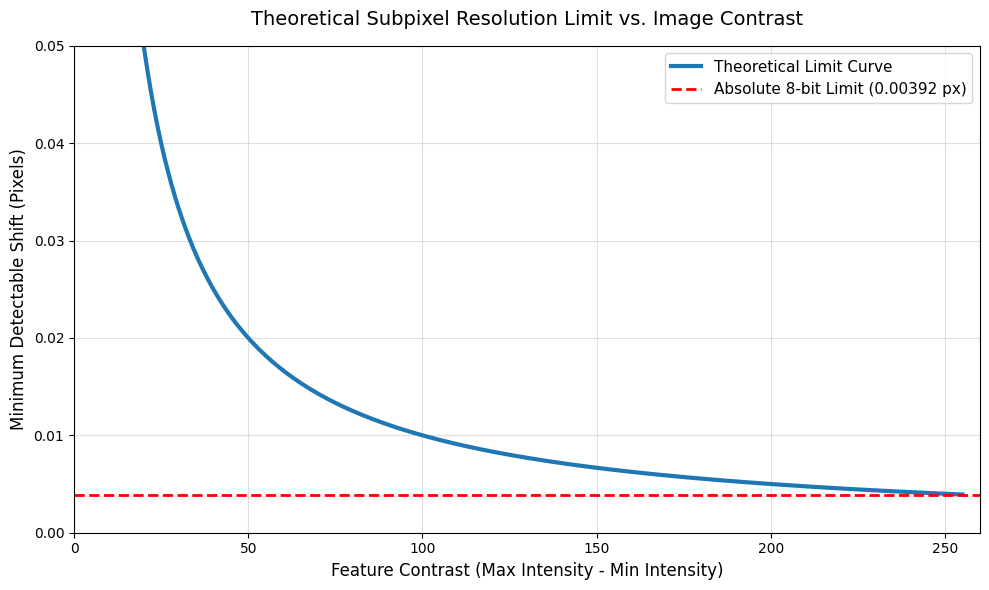

--- THEORETICAL LIMITS ---
Best possible accuracy (Contrast 255): 0.00392 pixels
Accuracy at lower contrast (e.g., 100) : 0.01000 pixels


In [1]:
import numpy as np
import matplotlib.pyplot as plt

def calculate_subpixel_limit(min_intensity, max_intensity):
    """Calculates the theoretical subpixel limit based on feature contrast."""
    contrast = max_intensity - min_intensity
    if contrast <= 0:
        return float('inf')
    return 1.0 / contrast

# Calculate limits for various contrast levels (from a contrast of 10 up to 255)
contrasts = np.arange(10, 256)
limits = [calculate_subpixel_limit(0, c) for c in contrasts]

# Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(contrasts, limits, color='#1f77b4', linewidth=3, label='Theoretical Limit Curve')
plt.axhline(y=1/255, color='red', linestyle='--', linewidth=2, label='Absolute 8-bit Limit (0.00392 px)')

plt.title('Theoretical Subpixel Resolution Limit vs. Image Contrast', fontsize=14, pad=15)
plt.xlabel('Feature Contrast (Max Intensity - Min Intensity)', fontsize=12)
plt.ylabel('Minimum Detectable Shift (Pixels)', fontsize=12)

plt.ylim(0, 0.05)
plt.xlim(0, 260)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

print("--- THEORETICAL LIMITS ---")
print(f"Best possible accuracy (Contrast 255): {calculate_subpixel_limit(0, 255):.5f} pixels")
print(f"Accuracy at lower contrast (e.g., 100) : {calculate_subpixel_limit(0, 100):.5f} pixels")